# Celltype abundances

In [1]:
here::i_am("rna_atac/clustering/02_clustering.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
      

In [3]:
args = list()

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/clustering/')

meta_annotated = fread(sprintf('%s/metadata_celltype_annotated.txt.gz', args$outdir))

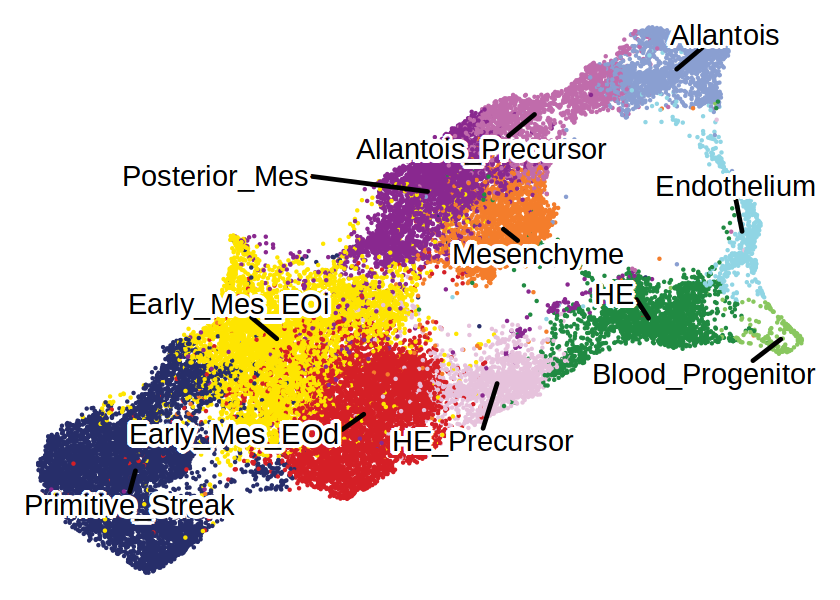

In [4]:
umap.dt = meta_annotated
labels = umap.dt[,`:=`(mean_UMAP1 = median(UMAP1),
                       mean_UMAP2 = median(UMAP2)), 
                       by=celltype_v1] %>% unique(by='celltype_v1')
p = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype_v1, label=celltype_v1)) + 
    geom_point(size=0.2) + 
    ggrepel::geom_text_repel(data=labels, aes(mean_UMAP1, mean_UMAP2), 
                             col='black', 
                             size=6,  
                             bg.color = "white", 
                             bg.r=0.2,
                             box.padding=1,
                             max.overlaps=Inf,
                             #   segment.curvature = -1,
                            segment.size = 1) +
    scale_color_manual(values=opts$celltype_v1.colors, name='') +
    guides(colour = guide_legend(override.aes = list(size=4))) +
    theme_void() +
     theme(text=element_text(size=15), 
          plot.title=element_text(size=40), 
          legend.position='none')#,
    #      legend.box="vertical", legend.margin=margin())

options(repr.plot.width=7, repr.plot.height=5)
p 

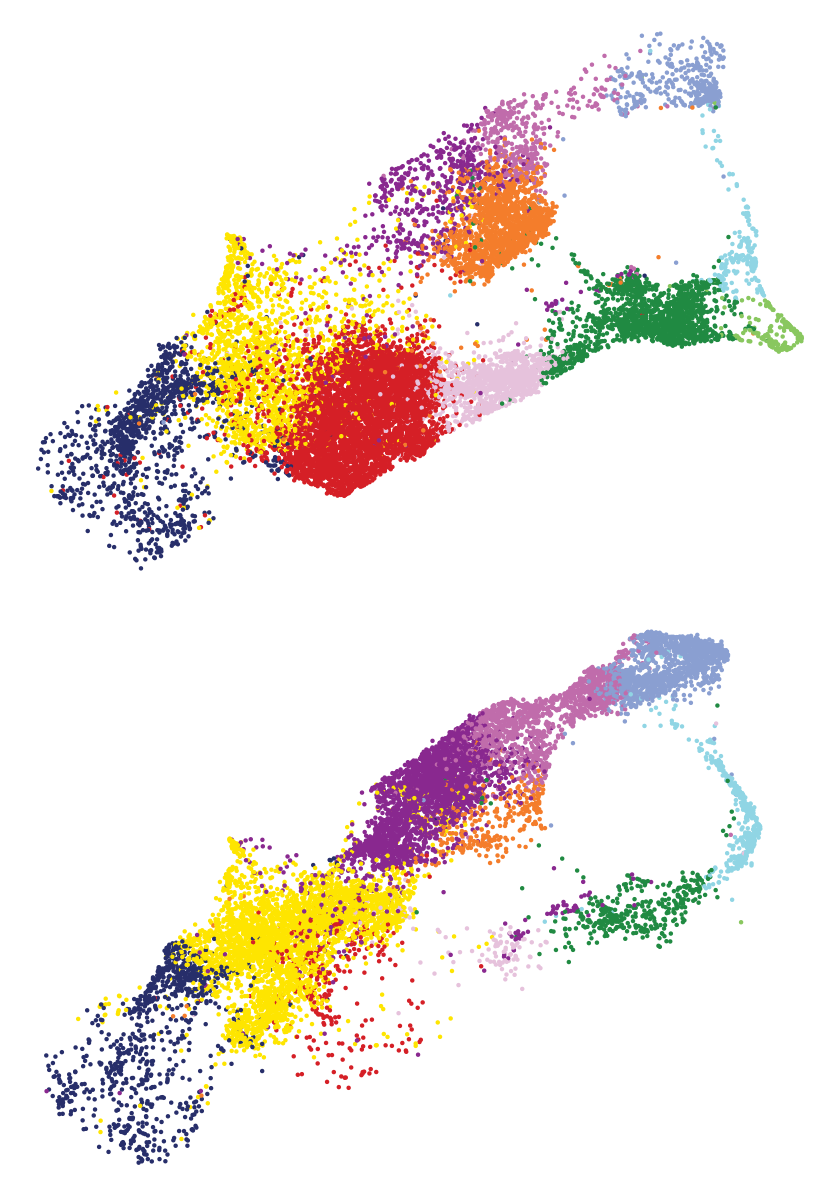

In [37]:
umap.dt = meta_annotated[day!='D3'] %>% .[,genotype:=factor(gsub('KO', 'Eomes KD', genotype), levels = c('WT', 'Eomes KD'))]
p = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype_v1, label=celltype_v1)) + 
    geom_point(size=0.2) + 
    scale_color_manual(values=opts$celltype_v1.colors, name='') +
    guides(colour = guide_legend(override.aes = list(size=4))) +
    facet_wrap(~genotype, ncol=1) + 
    theme_void() +
     theme(text=element_text(size=15), 
           #strip.text = element_text(size=30),
           strip.text = element_blank(),
          legend.position='none')#,
    #      legend.box="vertical", legend.margin=margin())

options(repr.plot.width=7, repr.plot.height=10)
p 

[1] "Primitive_Streak"    "Early_Mes_EOi"       "Early_Mes_EOd"      
 [4] "HE_Precursor"        "HE"                  "Blood_Progenitor"   
 [7] "Endothelium"         "Allantois"           "Allantois_Precursor"
[10] "Mesenchyme"          "Posterior_Mes"

In [27]:
meta = meta_annotated[day!='D3'][,genotype:=factor(gsub('KO', 'Eomes KD', genotype), levels = c('WT', 'Eomes KD'))]
prop = as.data.table(prop.table(table(meta$genotype, meta$celltype_v1), 1), keep.rownames=T) %>%
    setnames(c('genotype', 'celltype_v1', 'prop'))

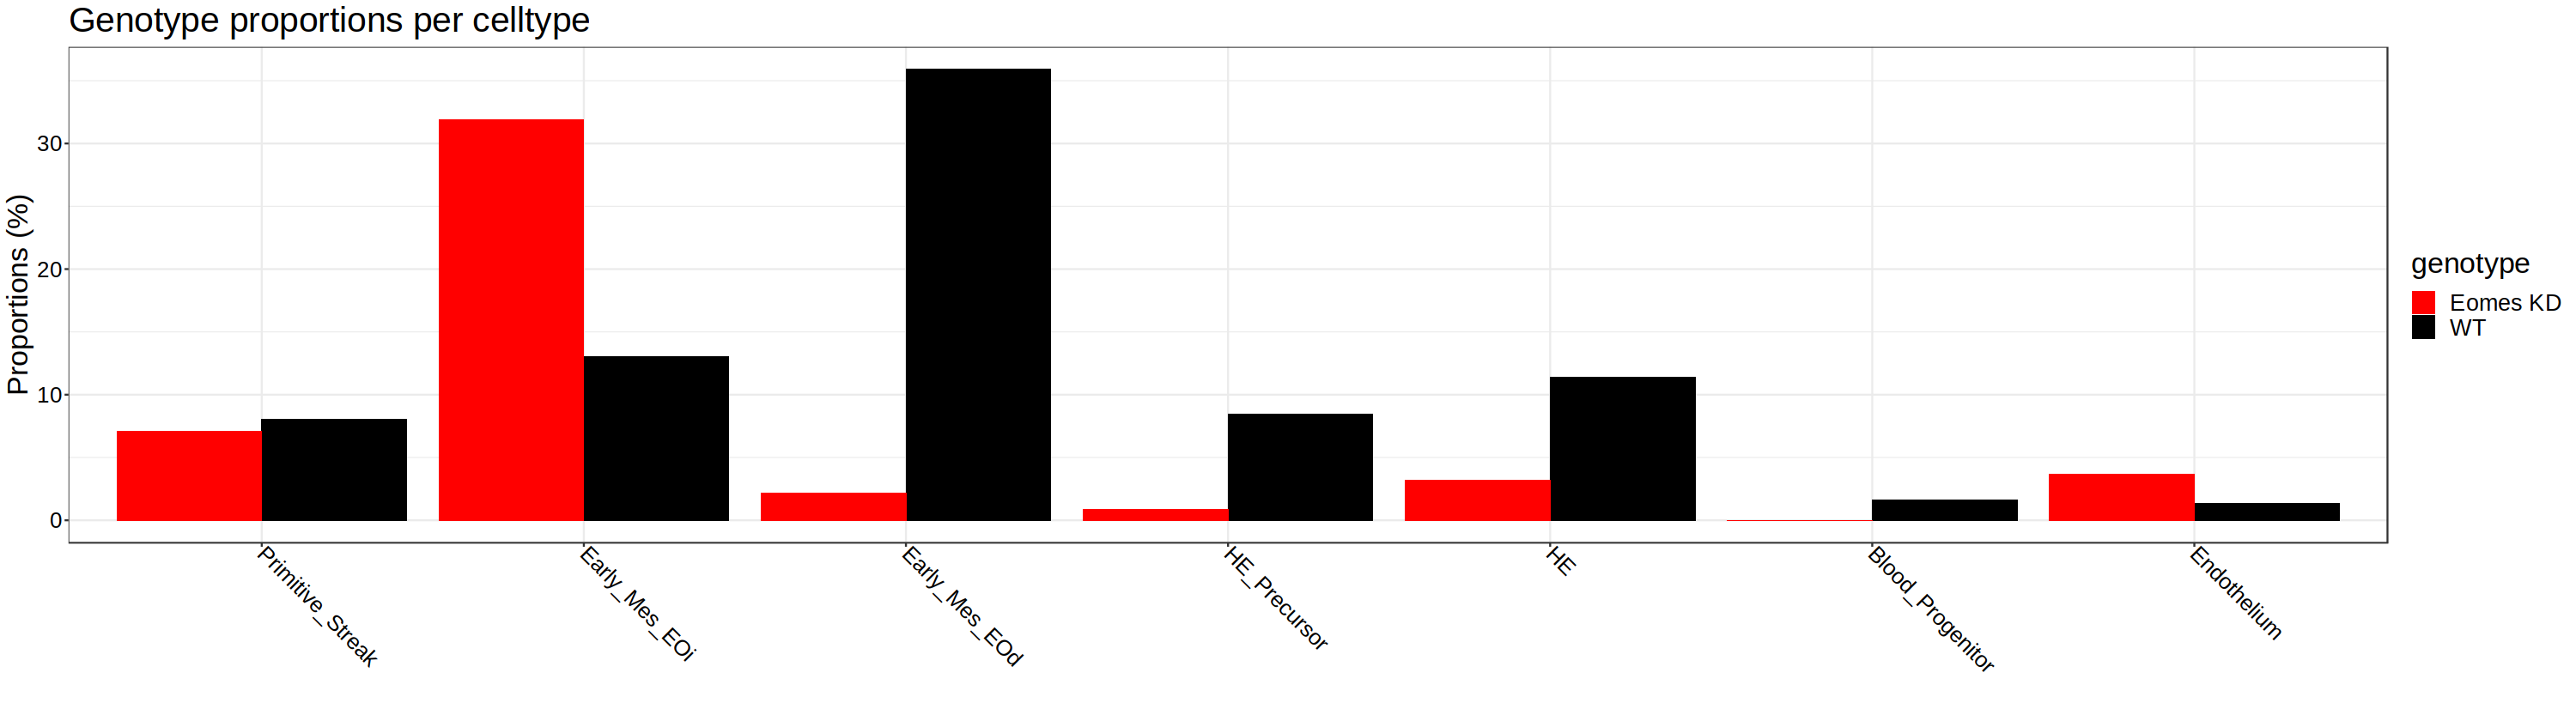

In [28]:
ggplot(prop[, celltype_v1:=factor(celltype_v1, levels = opts$celltype_levels)] %>% 
           .[celltype_v1 %in% c('Primitive_Streak','Early_Mes_EOi','Early_Mes_EOd','HE_Precursor','HE','Endothelium', 'Blood_Progenitor')]
           , aes(celltype_v1, prop*100, fill=genotype)) + 
    geom_bar(stat='identity', position='dodge') +
    scale_fill_manual(values=c('WT' = 'black', 'Eomes KD' = 'red'), name='genotype') + 
    xlab('') + ylab('Proportions (%)') + 
    ggtitle('Genotype proportions per celltype') +
    theme_bw() + 
    theme(text = element_text(size=20),
          axis.text = element_text(color='black', size = 15),
          axis.text.x = element_text(angle=-45, hjust=0, vjust=0.5))

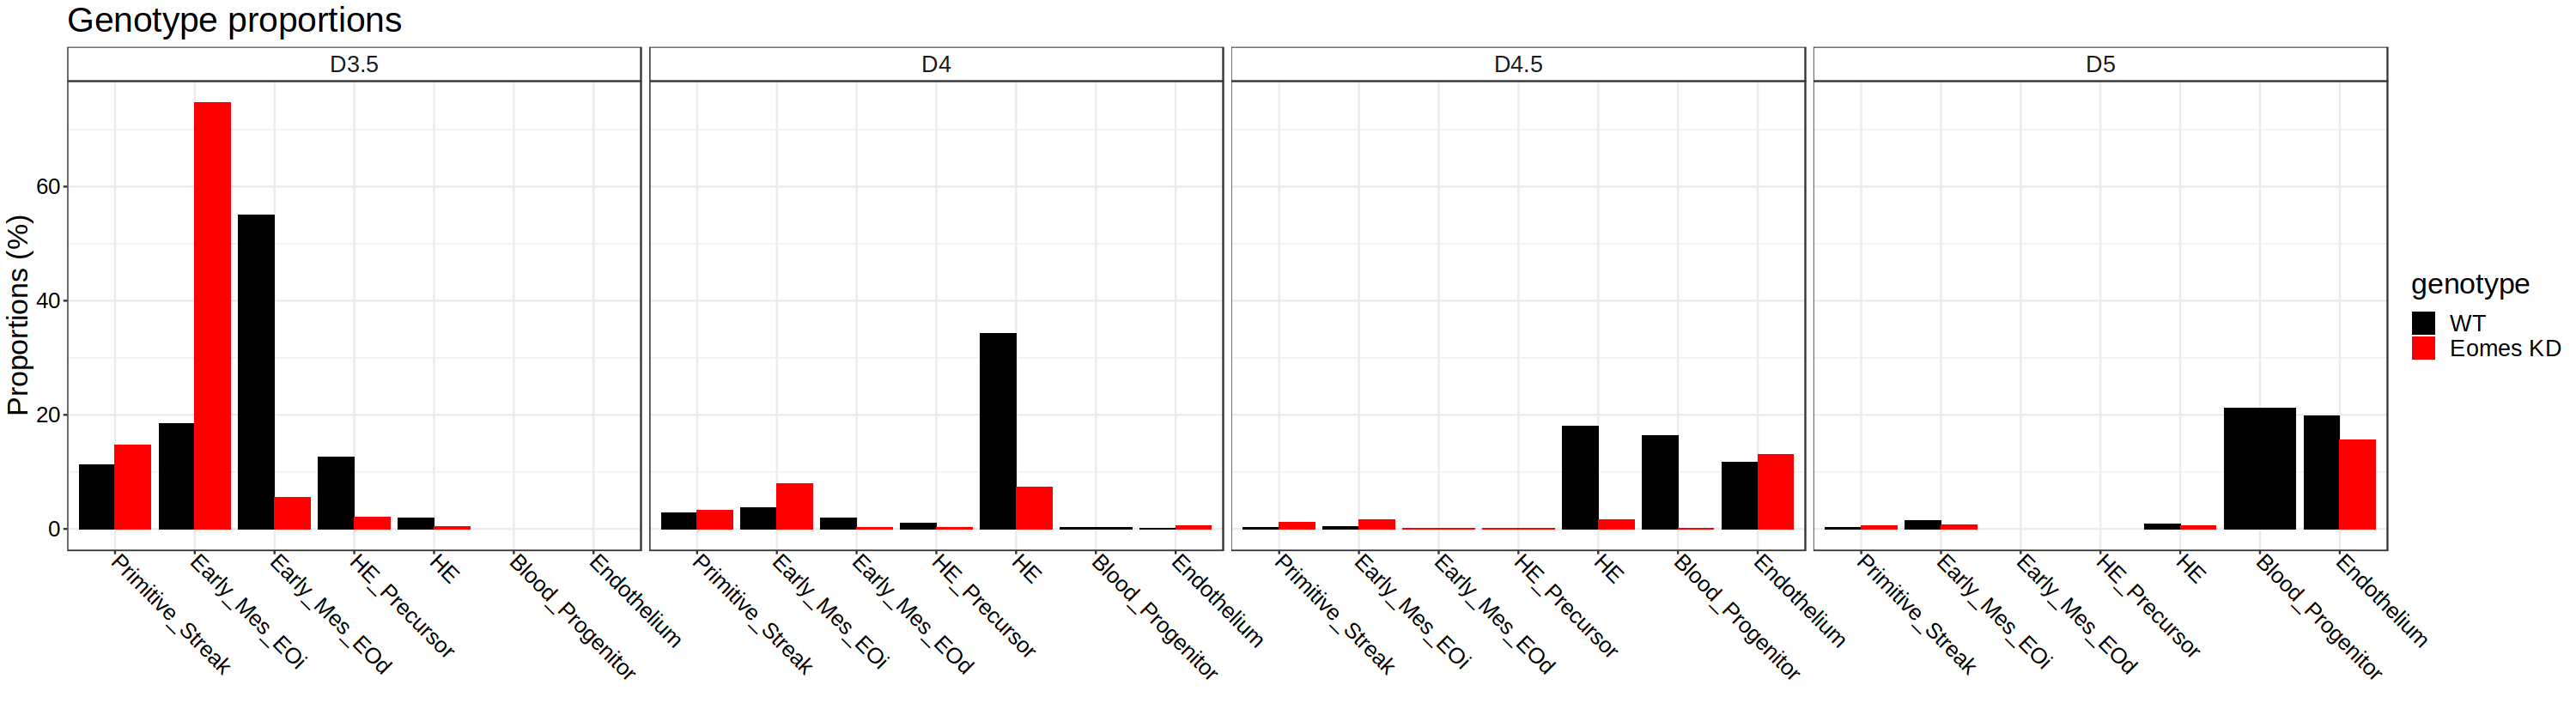

In [32]:
# Proportions per celltype & day
prop = meta %>%
    .[, Ntot := .N, by=c('day', 'genotype')] %>%
    .[, Ntest := .N, by=c('day', 'celltype_v1', 'genotype')] %>% 
    .[, prop := Ntest/Ntot*100] %>% unique( by=c('day', 'celltype_v1', 'genotype')) %>%
    .[,c('day', 'celltype_v1', 'genotype', 'prop')] %>% 
    .[, celltype_v1 := factor(celltype_v1, levels = opts$celltype_levels)]

options(repr.plot.width=25, repr.plot.height=7)
ggplot(prop[celltype_v1 %in% c('Primitive_Streak','Early_Mes_EOi','Early_Mes_EOd','HE_Precursor','HE','Endothelium', 'Blood_Progenitor')], aes(celltype_v1, prop, fill=genotype)) + 
    geom_bar(stat='identity', position='dodge') +
    scale_fill_manual(values=c('WT' = 'black', 'Eomes KD' = 'red'), name='genotype') + 
    xlab('') + ylab('Proportions (%)') + 
    ggtitle('Genotype proportions') +
    facet_wrap(~day, ncol=4) +
    theme_bw() + 
    theme(text = element_text(size=20),
          strip.background = element_rect(fill=NA),
          axis.text = element_text(color='black', size = 15),
          axis.text.x = element_text(angle=-45, hjust=0, vjust=0.5))

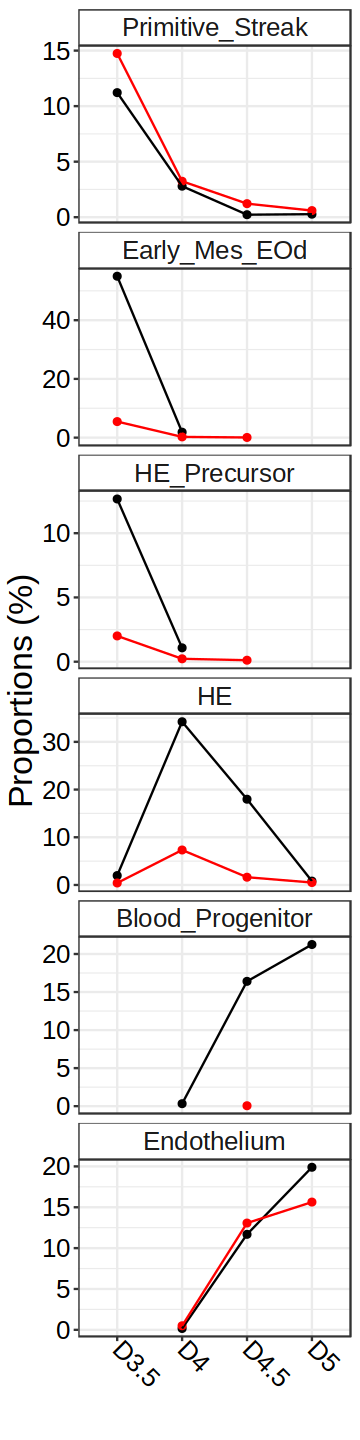

In [41]:
traj1 = c('Primitive_Streak', 'Early_Mes_EOd','HE_Precursor','HE','Endothelium', 'Blood_Progenitor')
options(repr.plot.width=3, repr.plot.height=12)
ggplot(prop[celltype_v1 %in% traj1], aes(day, prop, col=genotype, group=genotype)) + 
    geom_point() +
    geom_line() +
    scale_color_manual(values=c('WT' = 'black', 'Eomes KD' = 'red'), name='genotype') + 
    facet_wrap(~celltype_v1, ncol=1, scales='free_y') +
    xlab('') + ylab('Proportions (%)') + 
    theme_bw() + 
    theme(text = element_text(size=20),
          strip.background = element_rect(fill=NA),
          legend.position='none', 
          strip.text = element_text(size=15),
          axis.text = element_text(color='black', size = 15),
          axis.text.x = element_text(angle=-45, hjust=0, vjust=0.5))

In [ ]:
'Allantois''Allantois_Precursor''Mesenchyme''Posterior_Mes'

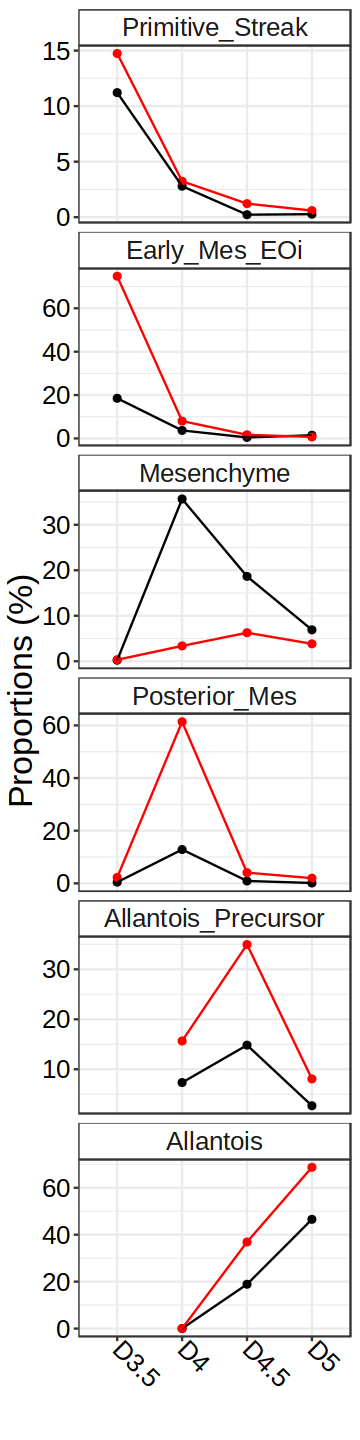

In [51]:
traj2 = c('Primitive_Streak', 'Early_Mes_EOi', 'Mesenchyme', 'Posterior_Mes','Allantois_Precursor', 'Allantois')
options(repr.plot.width=3, repr.plot.height=12)
ggplot(prop[celltype_v1 %in% traj2][,celltype_v1 := factor(celltype_v1, levels=traj2)], aes(day, prop, col=genotype, group=genotype)) + 
    geom_point() +
    geom_line() +
    scale_color_manual(values=c('WT' = 'black', 'Eomes KD' = 'red'), name='genotype') + 
    facet_wrap(~celltype_v1, ncol=1, scales='free_y') +
    xlab('') + ylab('Proportions (%)') + 
    theme_bw() + 
    theme(text = element_text(size=20),
          legend.position='none', 
          strip.background = element_rect(fill=NA),
          strip.text = element_text(size=15),
          axis.text = element_text(color='black', size = 15),
          axis.text.x = element_text(angle=-45, hjust=0, vjust=0.5))

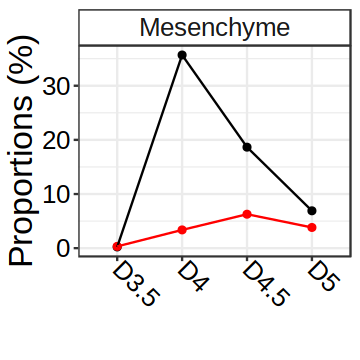

In [50]:
traj2 = c('Mesenchyme')
options(repr.plot.width=3, repr.plot.height=3)
ggplot(prop[celltype_v1 %in% traj2][,celltype_v1 := factor(celltype_v1, levels=traj2)], aes(day, prop, col=genotype, group=genotype)) + 
    geom_point() +
    geom_line() +
    scale_color_manual(values=c('WT' = 'black', 'Eomes KD' = 'red'), name='genotype') + 
    facet_wrap(~celltype_v1, ncol=1, scales='free_y') +
    xlab('') + ylab('Proportions (%)') + 
    theme_bw() + 
    theme(text = element_text(size=20),
          legend.position='none', 
          strip.background = element_rect(fill=NA),
          strip.text = element_text(size=15),
          axis.text = element_text(color='black', size = 15),
          axis.text.x = element_text(angle=-45, hjust=0, vjust=0.5))